In [1]:
import pandas as pd
import numpy as np

## Phase 1: Data Exploration & Initial Assessment

In [2]:
# 1.To Load The Traffic Dataset
traffic = pd.read_csv(r"C:\Users\saket\Downloads\Traffic_EDA_RandomIssues.csv")
traffic

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,01-06-2023,Thursday,NaN,2.0,2.0,24.0,NaN,normal
1,12:15:00 AM,01-06-2023,NaN,14.0,NaN,NaN,36.0,NaN,NaN
2,12:30:00 AM,01-06-2023,Thursday,NaN,2.0,2.0,32.0,46.0,normal
3,12:45:00 AM,01-06-2023,Thursday,10.0,NaN,2.0,36.0,NaN,normal
4,1:00:00 AM,01-06-2023,NaN,11.0,2.0,1.0,34.0,48.0,NaN
...,...,...,...,...,...,...,...,...,...
12404,2:45:00 AM,21-06-2023,Wednesday,9.0,0.0,NaN,24.0,NaN,NaN
12405,1:45:00 PM,14-06-2023,Wednesday,69.0,5.0,NaN,23.0,132.0,NaN
12406,11:30:00 AM,06-07-2023,Thursday,58.0,NaN,6.0,23.0,NaN,normal
12407,12:15:00 AM,26-06-2023,Monday,NaN,0.0,2.0,21.0,29.0,normal


In [3]:
#2.To preview the first few records
traffic.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,01-06-2023,Thursday,NaN,2.0,2.0,24.0,NaN,normal
1,12:15:00 AM,01-06-2023,NaN,14.0,NaN,NaN,36.0,NaN,NaN
2,12:30:00 AM,01-06-2023,Thursday,NaN,2.0,2.0,32.0,46.0,normal
3,12:45:00 AM,01-06-2023,Thursday,10.0,NaN,2.0,36.0,NaN,normal
4,1:00:00 AM,01-06-2023,NaN,11.0,2.0,1.0,34.0,48.0,NaN


In [4]:
# 3.Check structure and to inspect column data types and missing values.
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12409 entries, 0 to 12408
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               12409 non-null  object 
 1   Date               12409 non-null  object 
 2   Day of the week    9497 non-null   object 
 3   CarCount           9005 non-null   float64
 4   BikeCount          9064 non-null   float64
 5   BusCount           8934 non-null   float64
 6   TruckCount         9089 non-null   float64
 7   Total              9077 non-null   float64
 8   Traffic Situation  9530 non-null   object 
dtypes: float64(5), object(4)
memory usage: 872.6+ KB


In [5]:
traffic.shape

(12409, 9)

In [6]:
traffic.size

111681

In [7]:
# 4. Get summary stats and  to explore numerical data.
traffic.describe()

,CarCount,BikeCount,BusCount,TruckCount,Total
count,9005.000000,9064.000000,8934.000000,9089.000000,9077.000000
mean,65.032871,12.200022,12.717036,18.743426,108.855018
std,44.630499,11.566665,12.365305,10.989770,56.130092
min,5.000000,0.000000,0.000000,0.000000,21.000000
25%,18.000000,3.000000,1.000000,10.000000,54.000000
50%,62.000000,9.000000,10.000000,18.000000,104.000000
75%,102.000000,19.000000,20.000000,27.000000,153.000000
max,180.000000,70.000000,50.000000,60.000000,279.000000


In [8]:
# 5.To find missing values and count of null values in ecah column
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week      2912
CarCount             3404
BikeCount            3345
BusCount             3475
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [9]:
# 6.To Understand Categories of categorical columns
traffic.value_counts()

Time         Date        Day of the week  CarCount  BikeCount  BusCount  TruckCount  Total  Traffic Situation
5:45:00 PM   20-06-2023  Tuesday          100.0     8.0        13.0      11.0        132.0  normal               4
7:15:00 AM   12-06-2023  Monday           125.0     17.0       12.0      8.0         162.0  normal               4
9:15:00 PM   07-06-2023  Wednesday        61.0      10.0       14.0      35.0        120.0  high                 4
12:15:00 AM  09-06-2023  Friday           11.0      2.0        1.0       28.0        42.0   normal               3
4:30:00 AM   02-07-2023  Sunday           65.0      24.0       7.0       16.0        112.0  normal               3
                                                                                                                ..
2:30:00 AM   15-07-2023  Saturday         15.0      3.0        1.0       32.0        51.0   normal               1
             15-06-2023  Thursday         15.0      0.0        2.0       22.0        

## Phase 2: Data Manipulation & Preparation


## 1.Handle Missing Data

In [10]:
traffic.columns

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')

In [11]:
#Identify which columns have missing or null values
traffic.isnull().any()

Time                 False
Date                 False
Day of the week       True
CarCount              True
BikeCount             True
BusCount              True
TruckCount            True
Total                 True
Traffic Situation     True
dtype: bool

In [12]:
traffic["Day of the week"]=traffic["Day of the week"].fillna(traffic["Day of the week"].mode()[0])

In [13]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount             3404
BikeCount            3345
BusCount             3475
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [14]:
traffic["Day of the week"]=traffic["Day of the week"].fillna(traffic["Day of the week"].mode()[0])

In [15]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount             3404
BikeCount            3345
BusCount             3475
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [16]:
traffic["CarCount"]=traffic["CarCount"].fillna(traffic["CarCount"].mode()[0])

In [17]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount                0
BikeCount            3345
BusCount             3475
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [18]:
traffic["BikeCount"]=traffic["BikeCount"].fillna(traffic["BikeCount"].mode()[0])

In [19]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount                0
BikeCount               0
BusCount             3475
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [20]:
traffic["BusCount"]=traffic["BusCount"].fillna(traffic["BusCount"].mode()[0])

In [21]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount                0
BikeCount               0
BusCount                0
TruckCount           3320
Total                3332
Traffic Situation    2879
dtype: int64

In [22]:
traffic["TruckCount"]=traffic["TruckCount"].fillna(traffic["TruckCount"].mode()[0])

In [23]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount                0
BikeCount               0
BusCount                0
TruckCount              0
Total                3332
Traffic Situation    2879
dtype: int64

In [24]:
traffic["Total"]=traffic["Total"].fillna(traffic["Total"].mode()[0])

In [25]:
traffic.isnull().sum()

Time                    0
Date                    0
Day of the week         0
CarCount                0
BikeCount               0
BusCount                0
TruckCount              0
Total                   0
Traffic Situation    2879
dtype: int64

In [26]:
traffic["Traffic Situation"]=traffic["Traffic Situation"].fillna(traffic["Traffic Situation"].mode()[0])

In [27]:
traffic.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

### 2.Handling The Data

In [29]:
## checking for duplicates in data_set

In [28]:
traffic.duplicated().any()

True

In [31]:
#count duplicates

In [29]:
traffic.duplicated().sum()

1674

In [30]:
traffic.duplicated(keep="first")

0        False
1        False
2        False
3        False
4        False
         ...  
12404     True
12405     True
12406     True
12407     True
12408     True
Length: 12409, dtype: bool

In [34]:
## Dropping the duplicates

In [31]:
traffic = traffic.drop_duplicates()

In [32]:
traffic.duplicated().sum()

0

In [33]:
traffic

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,01-06-2023,Thursday,15.0,2.0,2.0,24.0,45.0,normal
1,12:15:00 AM,01-06-2023,Saturday,14.0,1.0,0.0,36.0,45.0,normal
2,12:30:00 AM,01-06-2023,Thursday,15.0,2.0,2.0,32.0,46.0,normal
3,12:45:00 AM,01-06-2023,Thursday,10.0,1.0,2.0,36.0,45.0,normal
4,1:00:00 AM,01-06-2023,Saturday,11.0,2.0,1.0,34.0,48.0,normal
...,...,...,...,...,...,...,...,...,...
11275,9:00:00 AM,24-07-2023,Monday,149.0,26.0,46.0,5.0,222.0,heavy
11276,7:00:00 AM,19-07-2023,Saturday,38.0,1.0,0.0,13.0,59.0,low
11277,5:45:00 PM,28-07-2023,Saturday,103.0,1.0,28.0,5.0,163.0,high
11279,4:15:00 PM,17-06-2023,Saturday,121.0,14.0,32.0,10.0,177.0,heavy


### Handling Outliers

In [38]:
## Detect outliers using IQR(interquartile Range)

In [34]:
Q1 = traffic["CarCount"].quantile(0.25)

In [35]:
Q3 = traffic["CarCount"].quantile(0.75)

In [36]:
IQR=Q3-Q1

In [37]:
IQR

70.0

In [38]:
lower_bound=Q1-1.5*IQR

In [39]:
upper_bound=Q3+1.5*IQR

In [40]:
outlier = traffic[(traffic["CarCount"]<lower_bound) | (traffic["CarCount"]>upper_bound)]

In [41]:
outlier

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

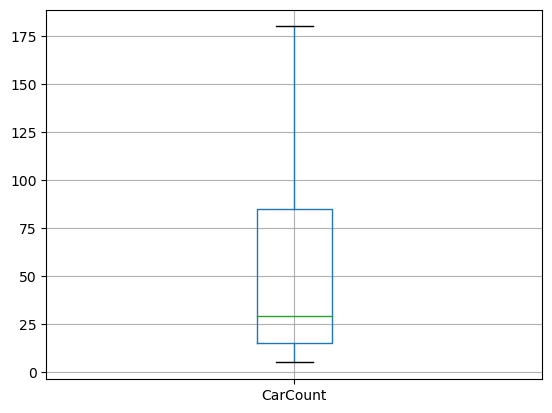

In [43]:
traffic.boxplot(column="CarCount")
plt.show()

## 3.Handling inconsistencies in data

In [44]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10735 entries, 0 to 11280
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               10735 non-null  object 
 1   Date               10735 non-null  object 
 2   Day of the week    10735 non-null  object 
 3   CarCount           10735 non-null  float64
 4   BikeCount          10735 non-null  float64
 5   BusCount           10735 non-null  float64
 6   TruckCount         10735 non-null  float64
 7   Total              10735 non-null  float64
 8   Traffic Situation  10735 non-null  object 
dtypes: float64(5), object(4)
memory usage: 838.7+ KB


In [45]:
traffic.dtypes

Time                  object
Date                  object
Day of the week       object
CarCount             float64
BikeCount            float64
BusCount             float64
TruckCount           float64
Total                float64
Traffic Situation     object
dtype: object

In [46]:
# lowercase the data and stripping spaces
traffic['Day of the week'] = traffic['Day of the week'].str.lower().str.strip()
traffic

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\1080971102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic['Day of the week'] = traffic['Day of the week'].str.lower().str.strip()


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,01-06-2023,thursday,15.0,2.0,2.0,24.0,45.0,normal
1,12:15:00 AM,01-06-2023,saturday,14.0,1.0,0.0,36.0,45.0,normal
2,12:30:00 AM,01-06-2023,thursday,15.0,2.0,2.0,32.0,46.0,normal
3,12:45:00 AM,01-06-2023,thursday,10.0,1.0,2.0,36.0,45.0,normal
4,1:00:00 AM,01-06-2023,saturday,11.0,2.0,1.0,34.0,48.0,normal
...,...,...,...,...,...,...,...,...,...
11275,9:00:00 AM,24-07-2023,monday,149.0,26.0,46.0,5.0,222.0,heavy
11276,7:00:00 AM,19-07-2023,saturday,38.0,1.0,0.0,13.0,59.0,low
11277,5:45:00 PM,28-07-2023,saturday,103.0,1.0,28.0,5.0,163.0,high
11279,4:15:00 PM,17-06-2023,saturday,121.0,14.0,32.0,10.0,177.0,heavy


In [47]:
traffic['Day of the week'].head()

0    thursday
1    saturday
2    thursday
3    thursday
4    saturday
Name: Day of the week, dtype: object

## 4.Covert Datatypes

In [53]:
# changing Num columns(floats) into int

In [48]:
traffic["CarCount"]=traffic["CarCount"].astype(int)

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\1101829055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["CarCount"]=traffic["CarCount"].astype(int)


In [49]:
traffic["BikeCount"] = traffic["BikeCount"].astype(int)

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\3085018179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["BikeCount"] = traffic["BikeCount"].astype(int)


In [50]:
traffic["BusCount"] = traffic["BusCount"].astype(int)

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\1196808490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["BusCount"] = traffic["BusCount"].astype(int)


In [51]:
traffic["TruckCount"] = traffic["TruckCount"].astype(int)

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\4286449897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["TruckCount"] = traffic["TruckCount"].astype(int)


In [52]:
traffic["Total"] = traffic["Total"].astype(int)

C:\Users\saket\AppData\Local\Temp\ipykernel_11112\931934151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["Total"] = traffic["Total"].astype(int)


In [53]:
traffic.dtypes

Time                 object
Date                 object
Day of the week      object
CarCount              int32
BikeCount             int32
BusCount              int32
TruckCount            int32
Total                 int32
Traffic Situation    object
dtype: object

In [60]:
## changing object to category

In [54]:
cols = ["Traffic Situation", "Day of the week"]
traffic[cols] = traffic[cols].astype("category")


C:\Users\saket\AppData\Local\Temp\ipykernel_11112\1202401589.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic[cols] = traffic[cols].astype("category")


In [58]:
traffic["Date"] = pd.to_datetime(traffic["Date"], format="%d-%m-%Y")


C:\Users\saket\AppData\Local\Temp\ipykernel_11112\1846797824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic["Date"] = pd.to_datetime(traffic["Date"], format="%d-%m-%Y")


In [61]:
traffic.dtypes

Time                         object
Date                 datetime64[ns]
Day of the week            category
CarCount                      int32
BikeCount                     int32
BusCount                      int32
TruckCount                    int32
Total                         int32
Traffic Situation          category
dtype: object

In [59]:
traffic

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,2023-06-01,thursday,15,2,2,24,45,normal
1,12:15:00 AM,2023-06-01,saturday,14,1,0,36,45,normal
2,12:30:00 AM,2023-06-01,thursday,15,2,2,32,46,normal
3,12:45:00 AM,2023-06-01,thursday,10,1,2,36,45,normal
4,1:00:00 AM,2023-06-01,saturday,11,2,1,34,48,normal
...,...,...,...,...,...,...,...,...,...
11275,9:00:00 AM,2023-07-24,monday,149,26,46,5,222,heavy
11276,7:00:00 AM,2023-07-19,saturday,38,1,0,13,59,low
11277,5:45:00 PM,2023-07-28,saturday,103,1,28,5,163,high
11279,4:15:00 PM,2023-06-17,saturday,121,14,32,10,177,heavy


In [64]:
## for initial unique values and counts
print(traffic['Day of the week'].value_counts())
print()

saturday     3743
friday       1205
sunday       1194
thursday     1194
monday       1179
tuesday      1164
wednesday    1056
Name: Day of the week, dtype: int64



In [65]:
print(traffic)

              Time        Date Day of the week  CarCount  BikeCount  BusCount  \
0      12:00:00 AM  01-06-2023        thursday        15          2         2   
1      12:15:00 AM  01-06-2023        saturday        14          1         0   
2      12:30:00 AM  01-06-2023        thursday        15          2         2   
3      12:45:00 AM  01-06-2023        thursday        10          1         2   
4       1:00:00 AM  01-06-2023        saturday        11          2         1   
...            ...         ...             ...       ...        ...       ...   
11275   9:00:00 AM  24-07-2023          monday       149         26        46   
11276   7:00:00 AM  19-07-2023        saturday        38          1         0   
11277   5:45:00 PM  28-07-2023        saturday       103          1        28   
11279   4:15:00 PM  17-06-2023        saturday       121         14        32   
11280  11:15:00 PM  01-08-2023        saturday        15          1         0   

       TruckCount  Total Tr

## 5.Univariate Analysis

* NUMERICAL

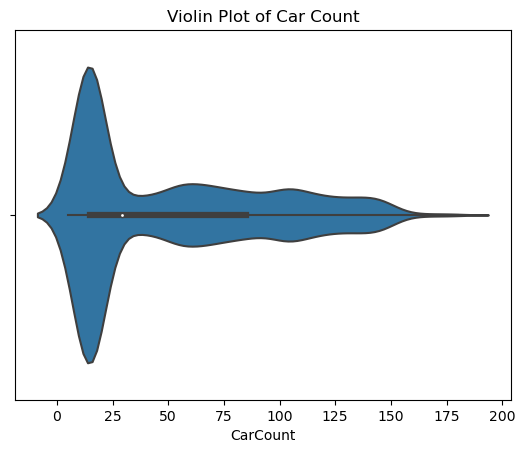

In [82]:
# VIOLIN PLOT
sns.violinplot(x=traffic["CarCount"])
plt.title("Violin Plot of Car Count")
plt.show()


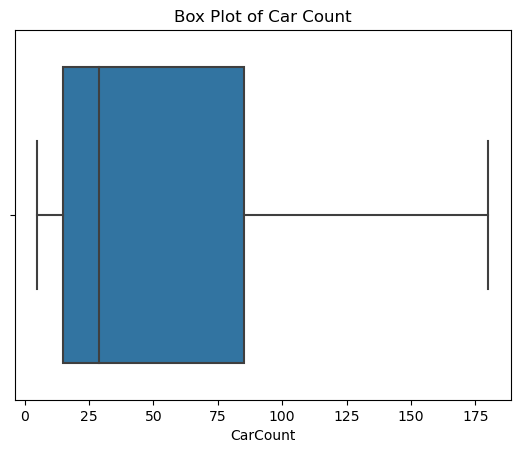

In [63]:
## BOX PLOT

sns.boxplot(x=traffic["CarCount"])
plt.title("Box Plot of Car Count")
plt.show()

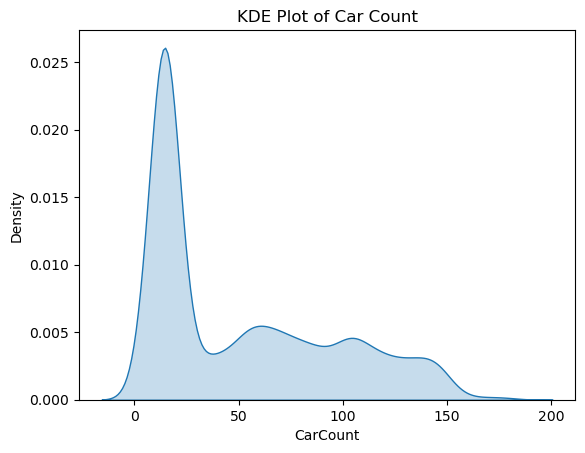

In [65]:
# KDE PLOT

sns.kdeplot(traffic["CarCount"], fill=True)
plt.title("KDE Plot of Car Count")
plt.show()


* CATEGORICAL

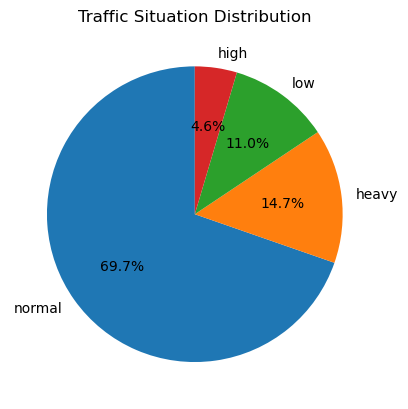

In [83]:
traffic["Traffic Situation"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Traffic Situation Distribution")
plt.ylabel("")
plt.show()

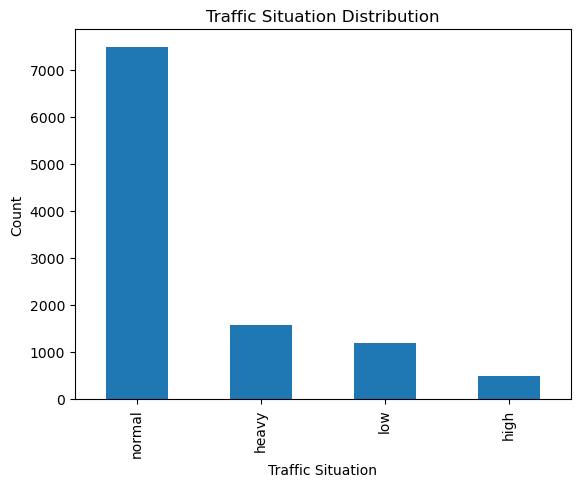

In [66]:
# BOX PLOT
traffic["Traffic Situation"].value_counts().plot(kind="bar")
plt.title("Traffic Situation Distribution")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.show()


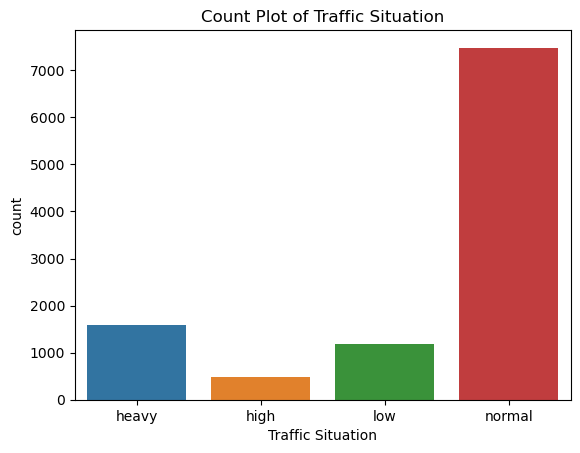

In [68]:
# COUNT PLOT
sns.countplot(x="Traffic Situation", data=traffic)
plt.title("Count Plot of Traffic Situation")
plt.show()


* DATE

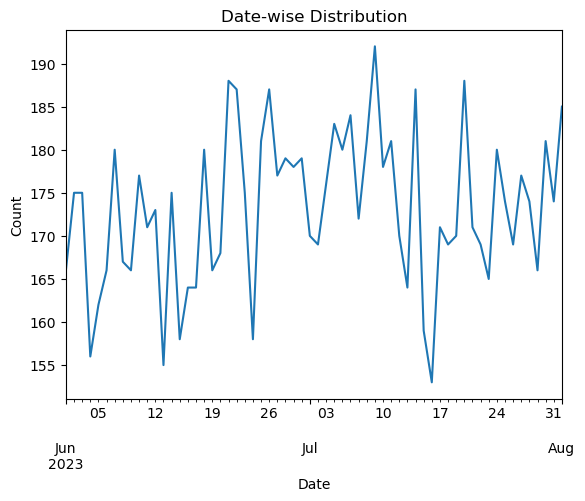

In [69]:
# LINE PLOT
traffic["Date"].value_counts().sort_index().plot(kind="line")
plt.title("Date-wise Distribution")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()


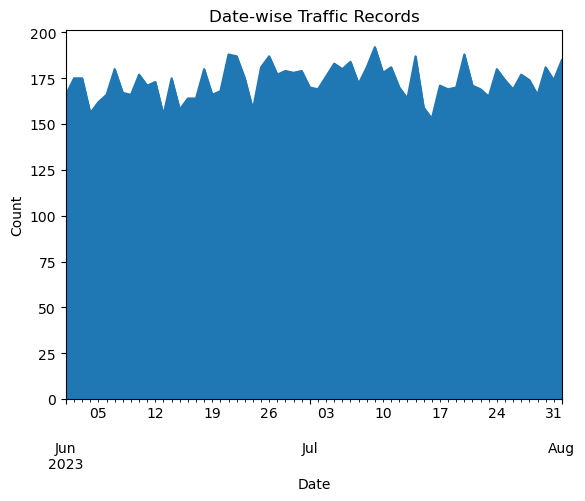

In [78]:
# BAR PLOT
traffic["Date"].value_counts().sort_index().plot(kind="area")
plt.title("Date-wise Traffic Records")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()



* TIME

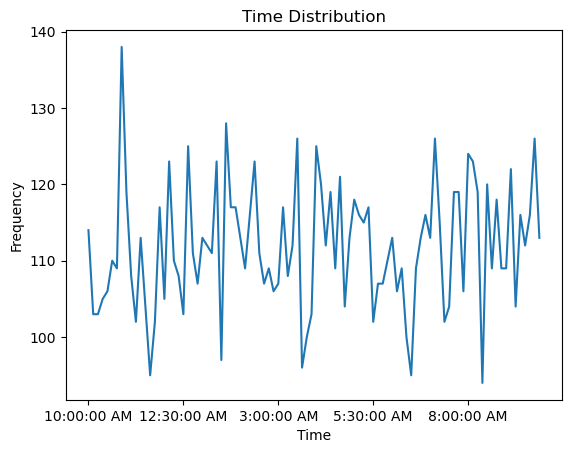

In [71]:
# LINE PLOT
traffic["Time"].value_counts().sort_index().plot(kind="line")
plt.title("Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()


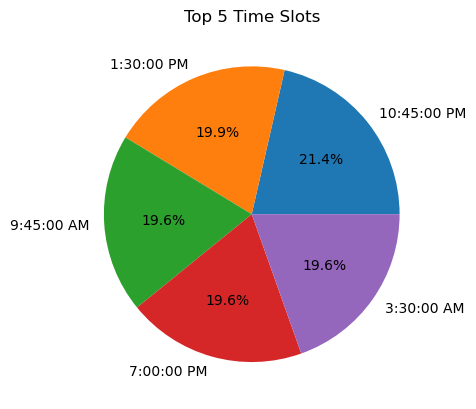

In [79]:
# AREA PLOT
traffic["Time"].value_counts().head(5).plot(kind="pie",autopct="%1.1f%%")
plt.title("Top 5 Time Slots")
plt.ylabel("")
plt.show()



## 6.Bivariate Analysis Using Visualization

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt 

* CATEGORICAL VS CATEGORICAL

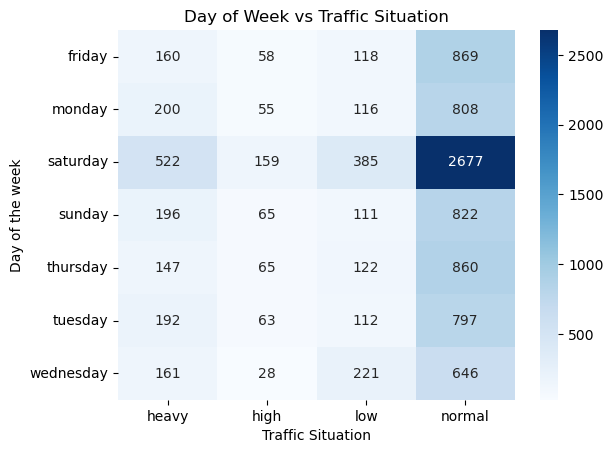

In [84]:
# HEAT MAP
ct = pd.crosstab(traffic["Day of the week"], traffic["Traffic Situation"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Day of Week vs Traffic Situation")
plt.show()

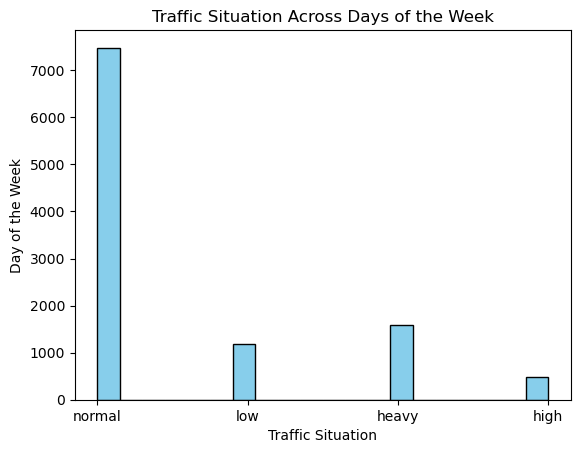

In [67]:
plt.hist(traffic["Traffic Situation"], bins=20, color='skyblue',edgecolor = 'black')
plt.title("Traffic Situation Across Days of the Week")
plt.xlabel("Traffic Situation")
plt.ylabel("Day of the Week")
plt.show()

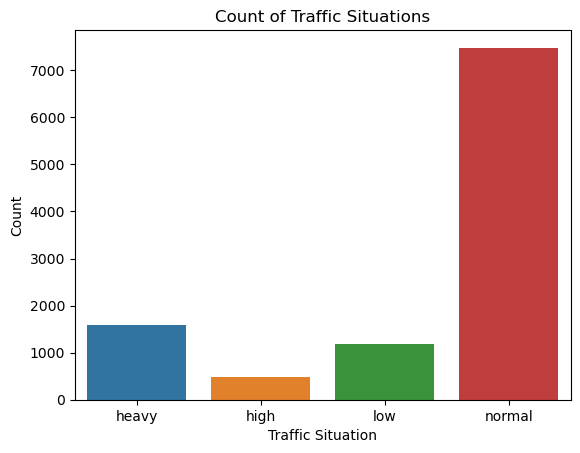

In [68]:
sns.countplot(data=traffic, x="Traffic Situation")
plt.title("Count of Traffic Situations")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.show()



* NUMERICAL VS CATEGORICAL

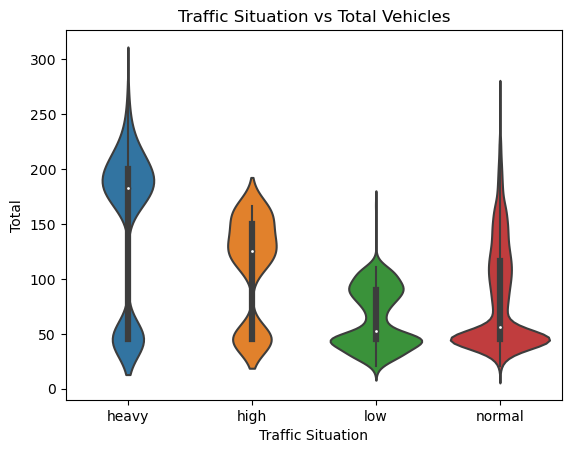

In [85]:
sns.violinplot(x="Traffic Situation", y="Total", data=traffic)
plt.title("Traffic Situation vs Total Vehicles")
plt.show()


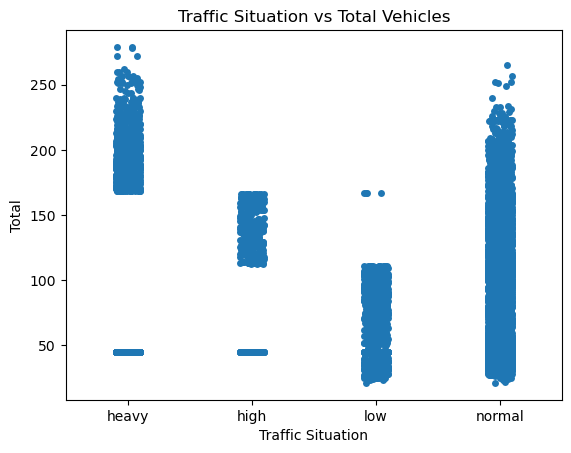

In [86]:
sns.stripplot(x="Traffic Situation", y="Total", data=traffic, jitter=True)
plt.title("Traffic Situation vs Total Vehicles")
plt.show()


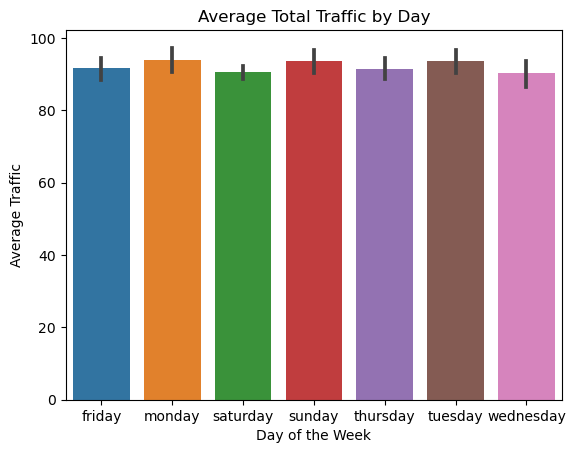

In [69]:
sns.barplot(data=traffic,x="Day of the week",y="Total")
plt.title("Average Total Traffic by Day")
plt.xlabel("Day of the Week")
plt.ylabel("Average Traffic")
plt.show()


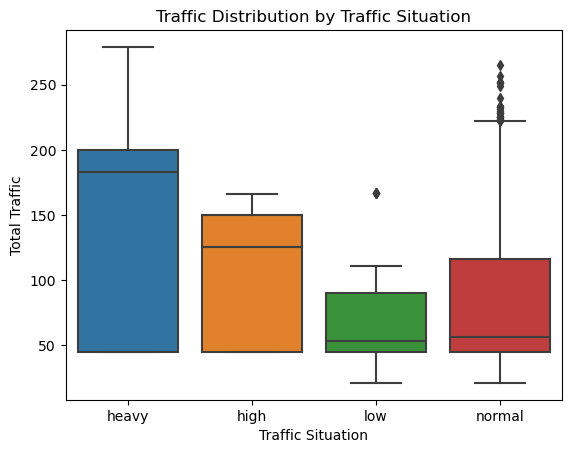

In [70]:
sns.boxplot(data=traffic,x="Traffic Situation",y="Total")
plt.title("Traffic Distribution by Traffic Situation")
plt.xlabel("Traffic Situation")
plt.ylabel("Total Traffic")
plt.show()


* Numerical vs Numerical

### 1.Scatter Plot

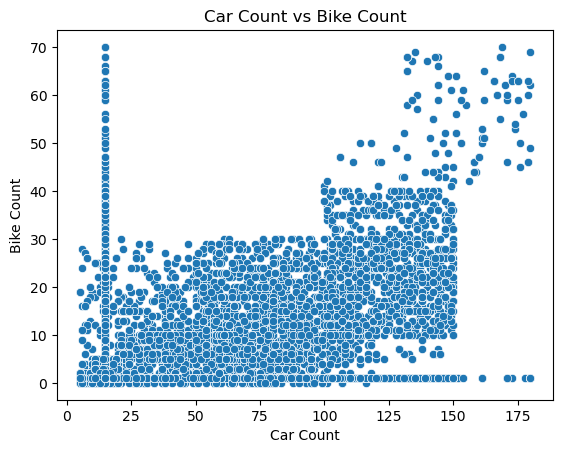

In [71]:
sns.scatterplot(data=traffic,x="CarCount",y="BikeCount")
plt.title("Car Count vs Bike Count")
plt.xlabel("Car Count")
plt.ylabel("Bike Count")
plt.show()


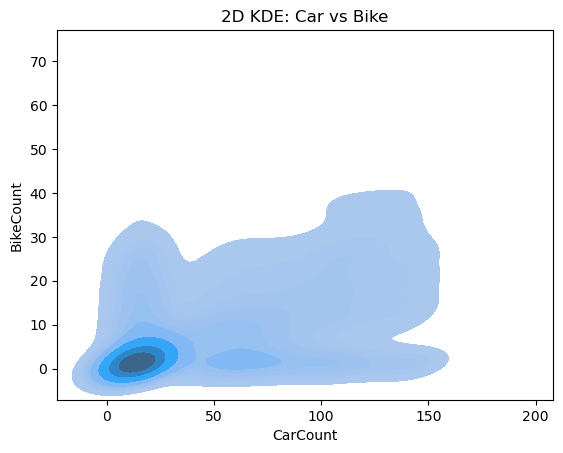

In [87]:
sns.kdeplot(x=traffic["CarCount"],y=traffic["BikeCount"],fill=True)
plt.title("2D KDE: Car vs Bike")
plt.show()


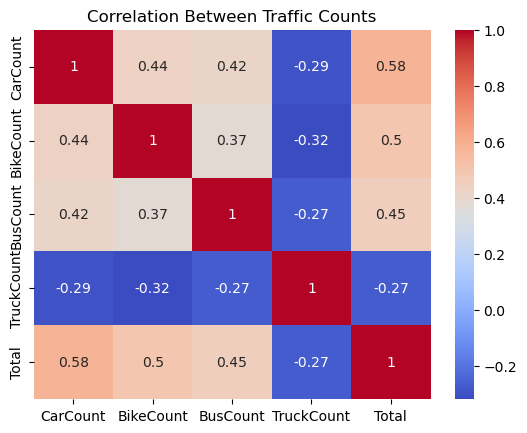

In [72]:
num_cols = ["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]
corr = traffic[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Traffic Counts")
plt.show()


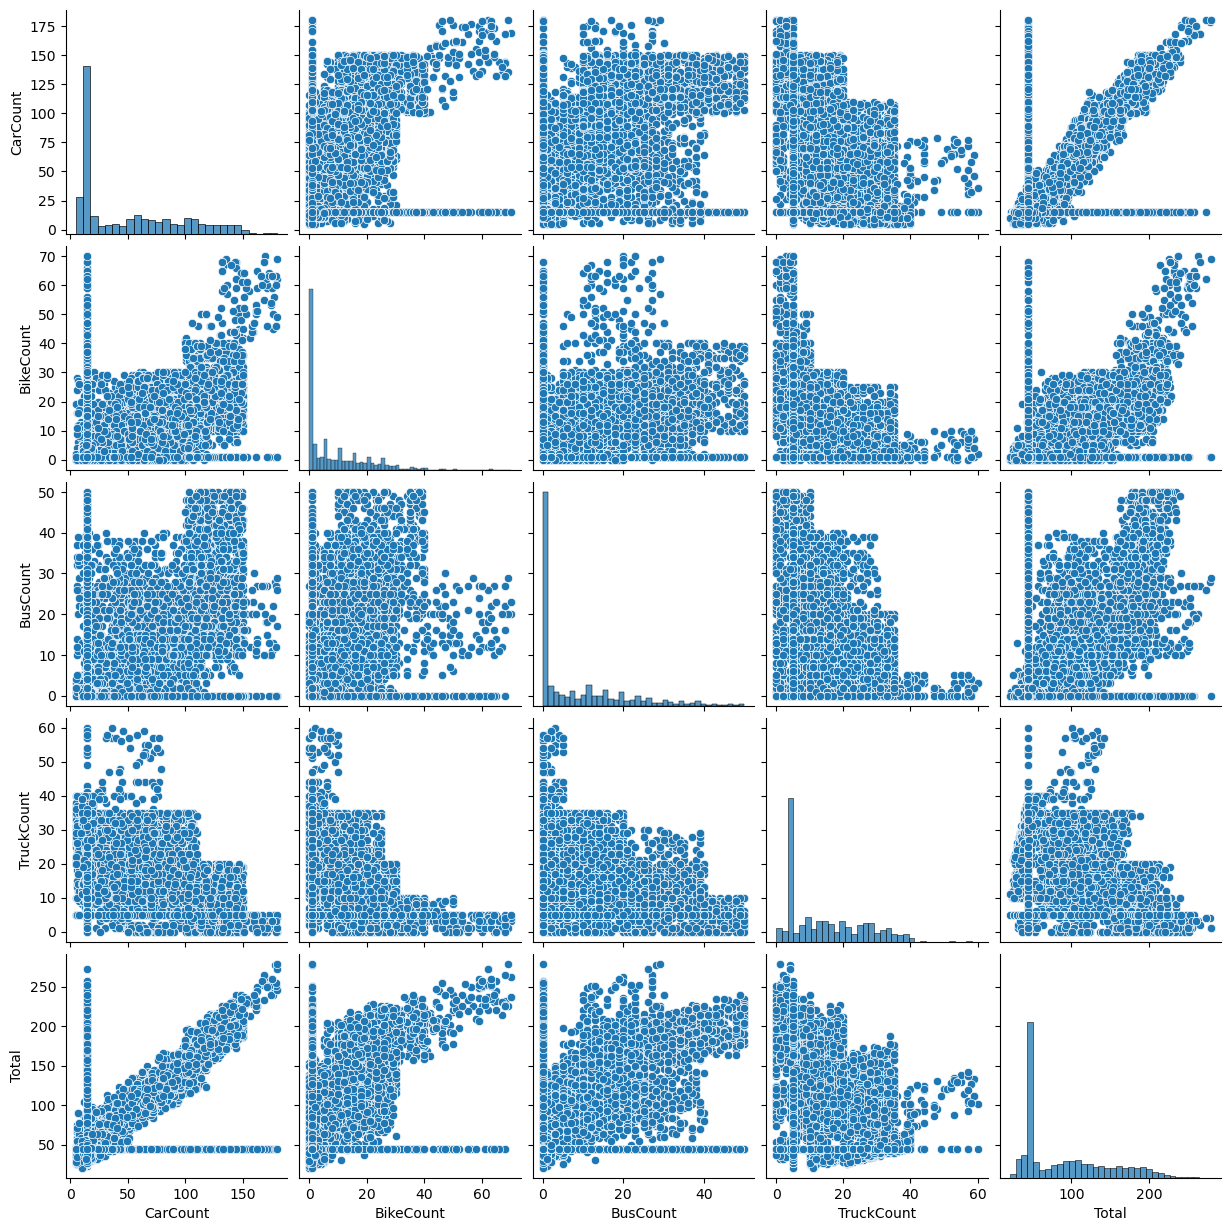

In [73]:
sns.pairplot(traffic[['CarCount','BikeCount','BusCount','TruckCount','Total']])
plt.show()